## 1. Configuração do ambiente =========================

In [142]:
# Bibliotecas básicas
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import os
import kagglehub

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Estatística
from scipy import stats

path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")
print("Path to dataset files:", path)

for filename in os.listdir(path):
    print(filename)

Path to dataset files: C:\Users\gustavo.dellanhol\.cache\kagglehub\datasets\yeanzc\telco-customer-churn-ibm-dataset\versions\1
Telco_customer_churn.xlsx


## 2. Carregamento dos dados =========================

### Sobre o Dataset

Shape, principais informações

Schema

In [143]:
import pandas as pd

df = pd.read_excel(path + "/Telco_customer_churn.xlsx")

print("Shape do dataset: ", df.shape)
df.head()


Shape do dataset:  (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [144]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
display(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
display(df.describe())

# Dropando a coluna Churn Score, que já contem previsão de churn e pode enviesar o modelo
if 'Churn Score' in df.columns: df.drop(columns=['Churn Score'], inplace=True)

# Dropando a coluna Count, que é irrelevante para a análise
if 'Count' in df.columns: df.drop(columns=['Count'], inplace=True)

# Tipando devidamente variáveis não numéricas
df[['Latitude', 'Longitude', 'Zip Code']] = df[['Latitude', 'Longitude', 'Zip Code']].astype(str)

# Tipando devidamente a variável `Total Charges`
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

print ("\n === COLUNAS NUMÉRICAS ===" )
# lista das colunas numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.to_list() 
print(num_cols)

# Renomear variável `Churn Value` para `target`
df.rename(columns={'Churn Value': 'target'}, inplace=True)

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null 

None


=== ESTATÍSTICAS DESCRITIVAS ===



,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000



 === COLUNAS NUMÉRICAS ===
['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


## 3. Análise Exploratória =========================

### 3.1 Missing Values

=== ANÁLISE DE MISSING VALUES ===

                      Coluna  Missing_Count  Missing_Percentage
Churn Reason    Churn Reason           5174               73.46
Total Charges  Total Charges             11                0.16


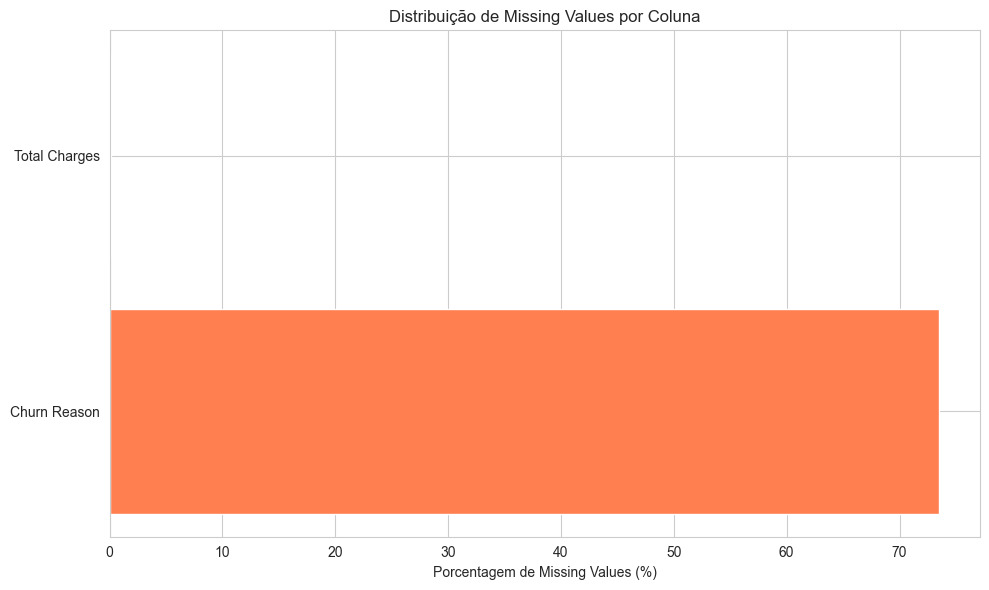

In [145]:
# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)
    
    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

In [ ]:
print("=== ANÁLISE DE MISSING VALUES NA COLUNA 'Churn Reason' ===")
print(df["Churn Reason"].isnull().sum())
df['Churn Reason'].fillna('Not churned', inplace=True)
print("\n Preenchido com 'Not Churned'")

print("\n=== ANÁLISE DE MISSING VALUES NA COLUNA 'Total Charges' ===")
print(df["Total Charges"].isnull().sum())
df['Total Charges'].fillna(0, inplace=True)
print("Preenchido com 0")

=== ANÁLISE DE MISSING VALUES NA COLUNA 'Churn Reason' ===
0

=== ANÁLISE DE MISSING VALUES NA COLUNA 'Total Charges' ===
11
Preenchido com 0


### 3.2 Variável Target

Distribuição e balanceamento das classes (Share)

Gráfico de pizza

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:


target
0    5174
1    1869
Name: count, dtype: int64


Percentual:
Não deixou a empresa (0): 73.46%
Deixou a empresa (1): 26.54%


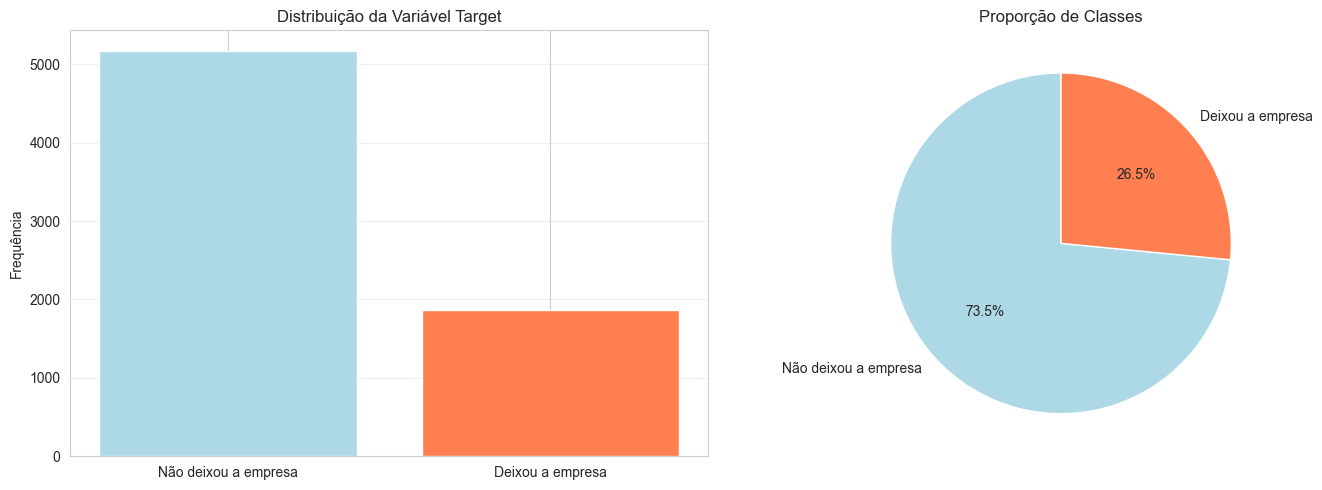


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [154]:
print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem:")
display(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Não deixou a empresa" if idx == 0 else "Deixou a empresa"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Não deixou a empresa', 'Deixou a empresa'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Não deixou a empresa', 'Deixou a empresa'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("✓ Dataset razoavelmente balanceado.")

### 3.3 Análise de Outliers

Boxplot e contagem de outliers com Z Score

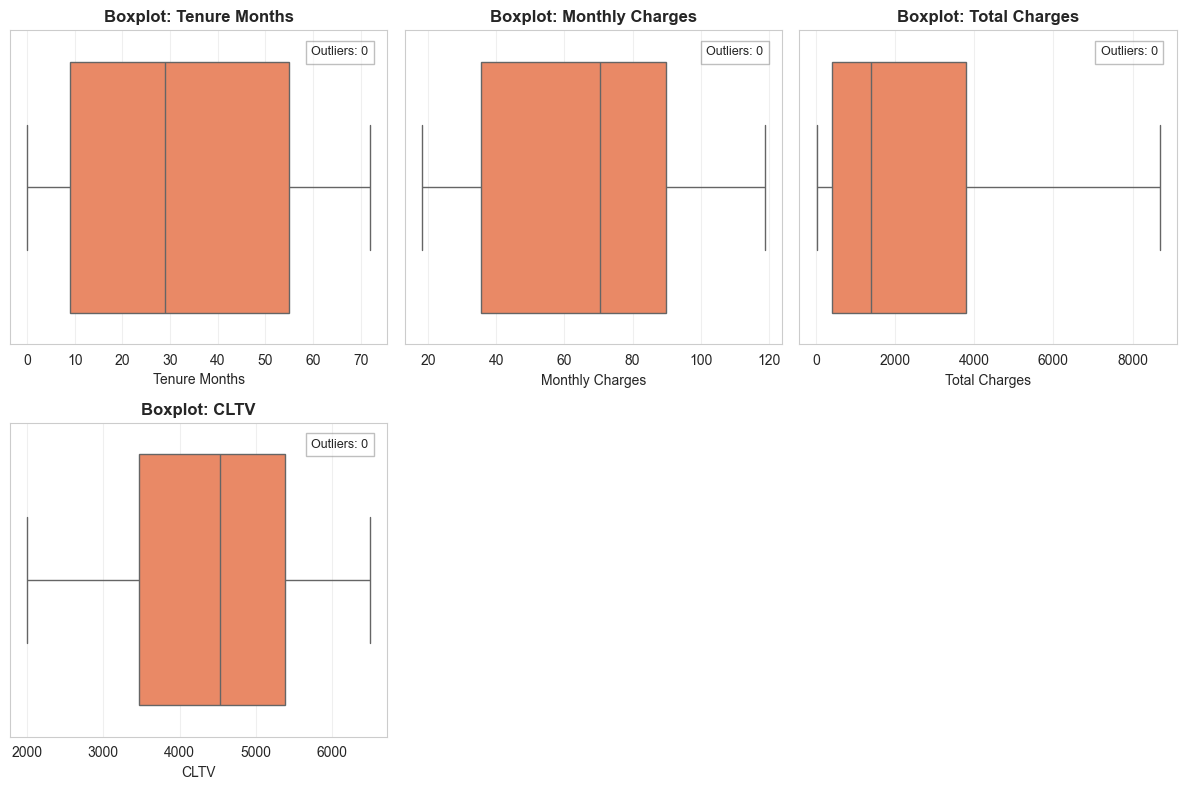

In [155]:
# Colunas numéricas (excluindo target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['target'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


### 3.4 Anomalias e valores inválidos

Valores fora do formato esperado

In [156]:
# Como não houve outliers significativos, não é necessário aplicar técnicas de tratamento.

### 3.5 Análise de Distribuições

Distribuição das variáveis numéricas (identificar assimetrias)

=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

         Coluna  Skewness  Kurtosis         Interpretação
  Tenure Months     0.240    -1.387                Normal
Monthly Charges    -0.221    -1.257                Normal
  Total Charges     0.962    -0.232 Assimétrica à direita
           CLTV    -0.312    -0.934                Normal


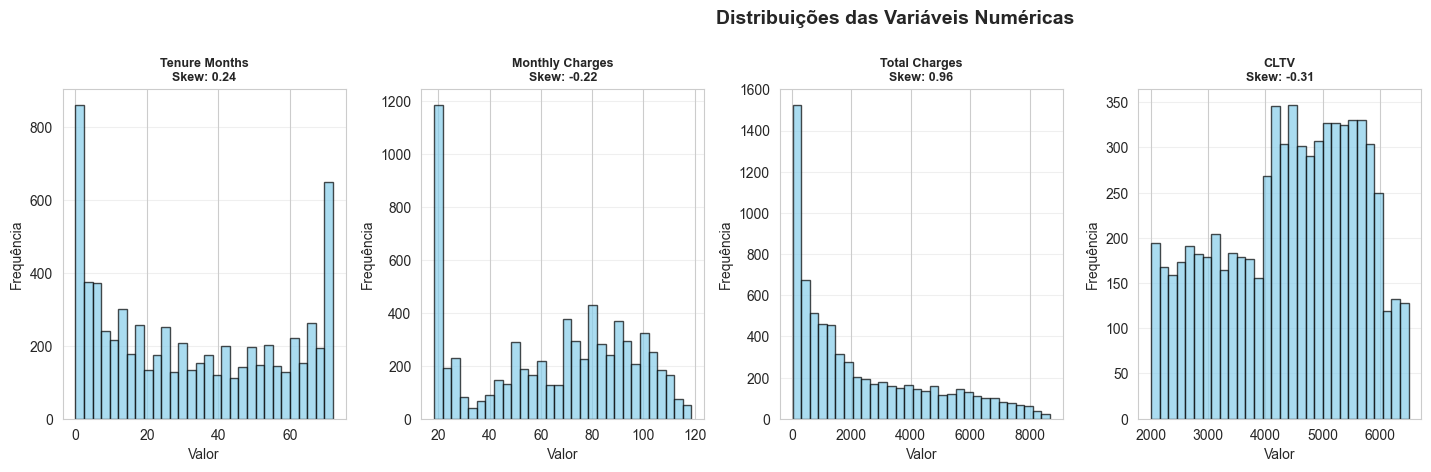

In [157]:
# Análise de distribuições
print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in numeric_cols:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizar distribuições
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 3.6 Análise de Correlações

Relações entre variáveis e detecção de multicolinearidade

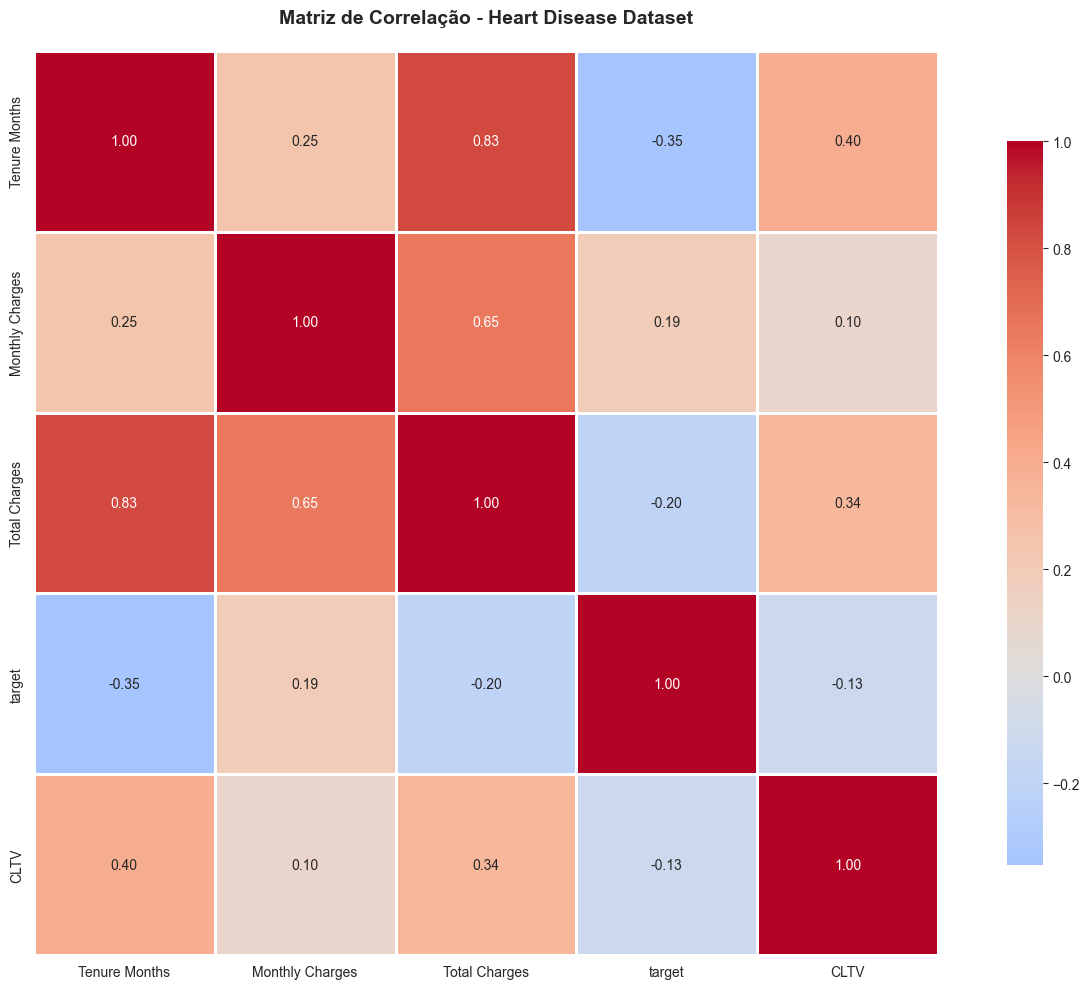

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

target             1.000000
Monthly Charges    0.193356
CLTV              -0.127463
Total Charges     -0.199484
Tenure Months     -0.352229
Name: target, dtype: float64

=== MULTICOLINEARIDADE (Correlação entre features) ===
Pares de features com correlação > 0.7:

    Feature 1     Feature 2  Correlação
Tenure Months Total Charges       0.826

⚠️ Alta correlação entre features pode causar multicolinearidade!


In [158]:
# Matriz de correlação apenas para colunas numéricas
corr_numeric = df.select_dtypes(include=[np.number]).corr()

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Heart Disease Dataset', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = corr_numeric['target'].sort_values(ascending=False)
print(target_corr)

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'target' and corr_numeric.columns[j] != 'target':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlação': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features (excluindo target)")

## 4. Preparação dos dados =========================

### 4.1 Tratamento de Missing Values

Definir se irá usar média/moda/mediana tanto para variáveis categóricas quanto para numéricas

Análise do quanto esse tratamento influenciou nas métricas

In [159]:
# Não existem Missing Values nesse dataset
# O único campo que apareceu Missing Values foi o "Churn Reason" com 5174 valores ausentes
# Isso é esperado, pois esse campo só é populado após a saída do cliente da empresa
# Como visto na seção de distribuição da variável target, temos a seguinte distribuição no dataset:
# 0    5174
# 1    1869
# Realizaremos a deleção dos seguintes campos:
# "Churn Reason" - não é um dado utilizado para inferência. É a rasão do cliente ter saído
# "Churn Label" - contém a mesma informação do campo "Churn Value"
# "Count" - possui o mesmo valor para todos os registros, não tem utilidade para o modelo

df = df.drop(columns=['Count', 'Churn Reason', 'Churn Label'])

KeyError: "['Count'] not found in axis"

### 4.2 One-hot Encoding


In [ ]:
# One-hot encoding das variáveis categóricas relevantes
categorical_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape após one-hot encoding: {df_encoded.shape}")
df_encoded.head()

Shape após one-hot encoding: (7043, 40)


,CustomerID,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Tenure Months,Monthly Charges,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,3668-QPYBK,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,2,53.85,...,False,False,False,False,False,False,True,False,False,True
1,9237-HQITU,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.30742,2,70.70,...,False,False,False,False,False,False,True,False,True,False
2,9305-CDSKC,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,8,99.65,...,False,True,False,True,False,False,True,False,True,False
3,7892-POOKP,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,28,104.80,...,False,True,False,True,False,False,True,False,True,False
4,0280-XJGEX,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,49,103.70,...,False,True,False,True,False,False,True,False,False,False


## 5. Persistir dataframe pré-processado  

In [ ]:
df_encoded.to_csv("../data/eda_output/Telco_customer_churn_encoded.csv", index=False)